# Historical Warning Patterns

This notebook investigates whether meteorological and hydrological
conditions show consistent patterns before historically observed flood
events across administrative areas in South Sudan.

The analysis is retrospective and exploratory. It does not produce
an operational flood forecast.

The main variables considered are:
- daily precipitation
- accumulated precipitation
- daily runoff
- accumulated runoff
- historical flood occurrence

The analysis focuses on detection, false alarms, missed events and
historical warning lead time.

In [4]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

# The notebook is inside dashboard_notebooks/
# so the repository root is one level up.
repo_root = Path.cwd().parent

# Make shared processing code importable
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

# loading.py expects ./raw_data/... relative to the repository root
os.chdir(repo_root)

print("Working directory:")
print(Path.cwd())

print("ERA5 file exists:")
print(Path("raw_data/rainfall and runoff/ERA5_2020.nc").exists())

from processing_data.loading import load_rainfall_runoff

Working directory:
c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026
ERA5 file exists:
True


In [5]:
years = np.array([2020])

rainfall_runoff = load_rainfall_runoff(years)

print(rainfall_runoff)

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2020-01-01 to 2020-12-31
<xarray.Dataset> Size: 24MB
Dimensions:     (valid_time: 366, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2020-01-01 ... 2020-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 12MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:    

In [6]:
print("Variables:")
print(list(rainfall_runoff.data_vars))

print("\nCoordinates:")
print("Latitude:", rainfall_runoff.latitude.min().item(), "to",
      rainfall_runoff.latitude.max().item())
print("Longitude:", rainfall_runoff.longitude.min().item(), "to",
      rainfall_runoff.longitude.max().item())

print("\nTime:")
print("Start:", rainfall_runoff.valid_time.min().item())
print("End:", rainfall_runoff.valid_time.max().item())

print("\nVariable attributes:")
print("tp:", rainfall_runoff["tp"].attrs)
print("ro:", rainfall_runoff["ro"].attrs)

Variables:
['tp', 'ro']

Coordinates:
Latitude: -3.0 to 33.0
Longitude: 23.0 to 37.0

Time:
Start: 1577836800000000000
End: 1609372800000000000

Variable attributes:
tp: {'GRIB_paramId': np.int64(228), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(8265), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(57), 'GRIB_Ny': np.int64(145), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(33.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-3.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np

In [7]:
print("Precipitation summary:")
print(rainfall_runoff["tp"].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 1]
).compute())

print("\nRunoff summary:")
print(rainfall_runoff["ro"].quantile(
    [0, 0.5, 0.9, 0.95, 0.99, 1]
).compute())

Precipitation summary:
<xarray.DataArray 'tp' (quantile: 6)> Size: 48B
array([0.        , 0.        , 0.00550461, 0.01048565, 0.02180009,
       0.37893581])
Coordinates:
  * quantile  (quantile) float64 48B 0.0 0.5 0.9 0.95 0.99 1.0
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      8265
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

Runoff summary:
<xarray.DataArray 'ro' (quantile: 6)> Size: 48B
array([0.    

In [11]:
from pathlib import Path

study_area_notebook = Path("dashboard_notebooks/02_define_study_areas.ipynb")

print(study_area_notebook.exists())
print(study_area_notebook.read_text(encoding="utf-8")[:15000])

True
{
 "cells": [
  {
   "cell_type": "code",
   "execution_count": 1,
   "id": "7474f72f",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import geopandas as gpd"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 2,
   "id": "e3cd2238",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "(10, 22)\n",
      "(79, 27)\n",
      "Index(['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode',\n",
      "       'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',\n",
      "       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',\n",
      "       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',\n",
      "       'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon',\n",
      "       'geometry'],\n",
      "      dtype='str')\n"
     ]
  

In [12]:
admin2 = gpd.read_file(
    "raw_data/Administrative boundaries/ssd_admin2.geojson"
)

print("admin2 shape:", admin2.shape)
print("Columns:")
print(admin2.columns.tolist())

admin2 shape: (79, 27)
Columns:
['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3', 'adm2_pcode', 'adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode', 'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode', 'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1', 'lang2', 'lang3', 'adm2_ref_name', 'center_lat', 'center_lon', 'geometry']


In [13]:
from shapely.geometry import box

south_sudan_bounds = admin2.total_bounds

era5_bounds = box(
    float(rainfall_runoff.longitude.min()),
    float(rainfall_runoff.latitude.min()),
    float(rainfall_runoff.longitude.max()),
    float(rainfall_runoff.latitude.max())
)

print("South Sudan bounds:")
print(south_sudan_bounds)

print("\nERA5 bounds:")
print(era5_bounds.bounds)

print("\nSouth Sudan intersects ERA5 coverage:")
print(admin2.geometry.intersects(era5_bounds).sum(), "of", len(admin2))

South Sudan bounds:
[24.15072456  3.48784008 35.95192367 12.23635188]

ERA5 bounds:
(23.0, -3.0, 37.0, 33.0)

South Sudan intersects ERA5 coverage:
79 of 79


In [14]:
print("ERA5 grid:")
print("Number of latitudes:", len(rainfall_runoff.latitude))
print("Number of longitudes:", len(rainfall_runoff.longitude))

print("\nLatitude spacing:")
print(np.diff(rainfall_runoff.latitude.values)[:5])

print("\nLongitude spacing:")
print(np.diff(rainfall_runoff.longitude.values)[:5])

ERA5 grid:
Number of latitudes: 145
Number of longitudes: 57

Latitude spacing:
[-0.25 -0.25 -0.25 -0.25 -0.25]

Longitude spacing:
[0.25 0.25 0.25 0.25 0.25]


In [15]:
ayod = admin2[admin2["adm2_name"] == "Ayod"].iloc[0]

print("Ayod:")
print("Area:", ayod["area_sqkm"], "km²")
print("Bounds:", ayod.geometry.bounds)
print("Centroid:", ayod.geometry.centroid)

Ayod:
Area: 13449.1465305 km²
Bounds: (30.272247314000083, 7.695336945000065, 31.707559138000192, 8.848113787000159)
Centroid: POINT (30.980148642308997 8.291711341783587)


In [16]:
from shapely.geometry import Point

era5_points = [
    Point(lon, lat)
    for lat in rainfall_runoff.latitude.values
    for lon in rainfall_runoff.longitude.values
]

era5_grid = gpd.GeoDataFrame(
    {"geometry": era5_points},
    crs="EPSG:4326"
)

ayod_overlapping = era5_grid[
    era5_grid.geometry.intersects(ayod.geometry)
]

print("ERA5 grid cells intersecting Ayod:", len(ayod_overlapping))

ERA5 grid cells intersecting Ayod: 19


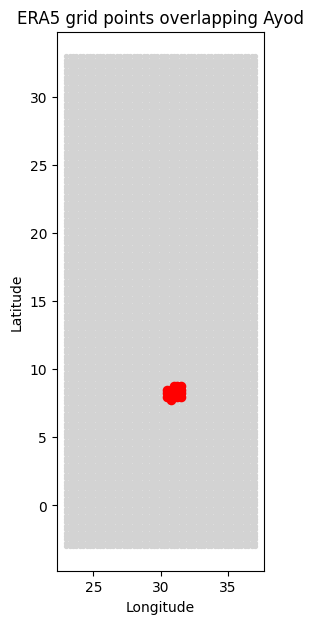

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))

ayod_gdf = gpd.GeoDataFrame(
    [ayod],
    geometry="geometry",
    crs=admin2.crs
)

ayod_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

era5_grid.plot(
    ax=ax,
    markersize=8,
    color="lightgray"
)

ayod_overlapping.plot(
    ax=ax,
    markersize=35,
    color="red"
)

ax.set_title("ERA5 grid points overlapping Ayod")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [18]:
admin_to_era5 = {}

for _, area in admin2.iterrows():
    points_inside = era5_grid[
        era5_grid.geometry.within(area.geometry)
    ]

    admin_to_era5[area["adm2_name"]] = points_inside.index.tolist()

# Summary
n_cells = pd.Series({
    area: len(indices)
    for area, indices in admin_to_era5.items()
})

print("Number of ERA5 grid points per administrative area:")
print(n_cells.describe())

print("\nAreas with no ERA5 grid points:")
print(n_cells[n_cells == 0])

print("\nAyod:")
print(n_cells["Ayod"])

Number of ERA5 grid points per administrative area:
count    79.000000
mean     10.607595
std      10.629444
min       0.000000
25%       6.000000
50%       8.000000
75%      12.000000
max      80.000000
dtype: float64

Areas with no ERA5 grid points:
Malakal    0
dtype: int64

Ayod:
19


In [19]:
malakal = admin2[admin2["adm2_name"] == "Malakal"].iloc[0]

print("Malakal area:", malakal["area_sqkm"], "km²")
print("Malakal bounds:", malakal.geometry.bounds)
print("Malakal centroid:", malakal.geometry.centroid)

Malakal area: 754.68040964 km²
Malakal bounds: (31.365995769000108, 9.446234659000083, 31.86756460900017, 9.898903704000077)
Malakal centroid: POINT (31.64279686743318 9.658456964478876)


In [20]:
from shapely.geometry import Polygon

lat_values = rainfall_runoff.latitude.values
lon_values = rainfall_runoff.longitude.values

# Calculate grid-cell boundaries from the midpoints between grid centres
lat_edges = np.empty(len(lat_values) + 1)
lon_edges = np.empty(len(lon_values) + 1)

lat_edges[1:-1] = (lat_values[:-1] + lat_values[1:]) / 2
lon_edges[1:-1] = (lon_values[:-1] + lon_values[1:]) / 2

# Extend the outer boundaries by half a grid spacing
lat_edges[0] = lat_values[0] + (lat_values[0] - lat_values[1]) / 2
lat_edges[-1] = lat_values[-1] + (lat_values[-1] - lat_values[-2]) / 2

lon_edges[0] = lon_values[0] - (lon_values[1] - lon_values[0]) / 2
lon_edges[-1] = lon_values[-1] + (lon_values[-1] - lon_values[-2]) / 2

grid_cells = []

for i, lat in enumerate(lat_values):
    for j, lon in enumerate(lon_values):
        cell = Polygon([
            (lon_edges[j],     lat_edges[i]),
            (lon_edges[j + 1], lat_edges[i]),
            (lon_edges[j + 1], lat_edges[i + 1]),
            (lon_edges[j],     lat_edges[i + 1])
        ])

        grid_cells.append({
            "lat_idx": i,
            "lon_idx": j,
            "latitude": lat,
            "longitude": lon,
            "geometry": cell
        })

era5_cells = gpd.GeoDataFrame(
    grid_cells,
    crs="EPSG:4326"
)

print("Number of ERA5 grid cells:", len(era5_cells))
print("Expected:", len(lat_values) * len(lon_values))

Number of ERA5 grid cells: 8265
Expected: 8265


In [21]:
malakal_cells = era5_cells[
    era5_cells.geometry.intersects(malakal.geometry)
]

print("ERA5 grid cells overlapping Malakal:", len(malakal_cells))

print("\nOverlapping grid cells:")
print(
    malakal_cells[
        ["latitude", "longitude"]
    ].to_string(index=False)
)

ERA5 grid cells overlapping Malakal: 6

Overlapping grid cells:
 latitude  longitude
    10.00      31.50
     9.75      31.25
     9.75      31.50
     9.75      31.75
     9.50      31.50
     9.50      31.75


In [22]:
admin_to_era5 = {}

for _, area in admin2.iterrows():
    overlapping_cells = era5_cells[
        era5_cells.geometry.intersects(area.geometry)
    ]

    admin_to_era5[area["adm2_name"]] = overlapping_cells.index.tolist()

# Number of ERA5 cells per administrative area
n_cells = pd.Series({
    area: len(indices)
    for area, indices in admin_to_era5.items()
})

print("ERA5 cells per administrative area:")
print(n_cells.describe())

print("\nAreas with no overlapping ERA5 cells:")
print(n_cells[n_cells == 0])

print("\nSelected areas:")
print(n_cells[["Ayod", "Malakal"]])

ERA5 cells per administrative area:
count     79.000000
mean      20.873418
std       14.178683
min        6.000000
25%       14.000000
50%       17.000000
75%       26.000000
max      112.000000
dtype: float64

Areas with no overlapping ERA5 cells:
Series([], dtype: int64)

Selected areas:
Ayod       29
Malakal     6
dtype: int64


In [23]:
# Use an equal-area CRS so overlap areas are comparable
admin_equal_area = admin2.to_crs("EPSG:6933")
era5_cells_equal_area = era5_cells.to_crs("EPSG:6933")

admin_to_era5_weights = {}

for _, area in admin_equal_area.iterrows():

    overlapping = era5_cells_equal_area[
        era5_cells_equal_area.geometry.intersects(area.geometry)
    ].copy()

    # Calculate the actual intersection area
    overlapping["intersection_area"] = overlapping.geometry.intersection(
        area.geometry
    ).area

    # Keep only positive overlaps
    overlapping = overlapping[
        overlapping["intersection_area"] > 0
    ].copy()

    # Normalize so weights sum to 1 within each administrative area
    overlapping["weight"] = (
        overlapping["intersection_area"]
        / overlapping["intersection_area"].sum()
    )

    admin_to_era5_weights[area["adm2_name"]] = overlapping[
        ["lat_idx", "lon_idx", "latitude", "longitude", "weight"]
    ].reset_index(drop=True)

print("Ayod:")
print(admin_to_era5_weights["Ayod"])

print("\nMalakal:")
print(admin_to_era5_weights["Malakal"])

Ayod:
    lat_idx  lon_idx  latitude  longitude    weight
0        97       30      8.75      30.50  0.003920
1        97       31      8.75      30.75  0.016593
2        97       32      8.75      31.00  0.042475
3        97       33      8.75      31.25  0.043821
4        97       34      8.75      31.50  0.019403
5        98       29      8.50      30.25  0.006918
6        98       30      8.50      30.50  0.054889
7        98       31      8.50      30.75  0.056590
8        98       32      8.50      31.00  0.056590
9        98       33      8.50      31.25  0.056590
10       98       34      8.50      31.50  0.043562
11       98       35      8.50      31.75  0.005071
12       99       29      8.25      30.25  0.008507
13       99       30      8.25      30.50  0.056626
14       99       31      8.25      30.75  0.056626
15       99       32      8.25      31.00  0.056626
16       99       33      8.25      31.25  0.056626
17       99       34      8.25      31.50  0.051138
18    

In [24]:
weight_sums = pd.Series({
    area: weights["weight"].sum()
    for area, weights in admin_to_era5_weights.items()
})

print("Weight sums:")
print(weight_sums.describe())

print("\nAreas where weights do not sum to 1:")
print(weight_sums[~np.isclose(weight_sums, 1.0)])

print("\nNumber of cells used:")
print(pd.Series({
    area: len(weights)
    for area, weights in admin_to_era5_weights.items()
}).describe())

Weight sums:
count    7.900000e+01
mean     1.000000e+00
std      1.269589e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Areas where weights do not sum to 1:
Series([], dtype: float64)

Number of cells used:
count     79.000000
mean      20.873418
std       14.178683
min        6.000000
25%       14.000000
50%       17.000000
75%       26.000000
max      112.000000
dtype: float64


In [26]:
# Load the ERA5 variables into memory once
tp_data = rainfall_runoff["tp"].compute().values
ro_data = rainfall_runoff["ro"].compute().values

print("ERA5 arrays loaded:")
print("Precipitation shape:", tp_data.shape)
print("Runoff shape:", ro_data.shape)

area_weather = {}

dates = pd.to_datetime(rainfall_runoff.valid_time.values)

for area_name, weights in admin_to_era5_weights.items():

    tp_values = tp_data[
        :,
        weights["lat_idx"].values,
        weights["lon_idx"].values
    ]

    ro_values = ro_data[
        :,
        weights["lat_idx"].values,
        weights["lon_idx"].values
    ]

    w = weights["weight"].values

    # Area-weighted mean
    tp_area = np.sum(tp_values * w[None, :], axis=1)
    ro_area = np.sum(ro_values * w[None, :], axis=1)

    area_weather[area_name] = pd.DataFrame({
        "date": dates,
        "precipitation_m": tp_area,
        "runoff_m": ro_area
    }).set_index("date")

print("\nFinished.")
print("Number of areas:", len(area_weather))
print("\nAyod:")
print(area_weather["Ayod"].head())

ERA5 arrays loaded:
Precipitation shape: (366, 145, 57)
Runoff shape: (366, 145, 57)

Finished.
Number of areas: 79

Ayod:
            precipitation_m  runoff_m
date                                 
2020-01-01              0.0       0.0
2020-01-02              0.0       0.0
2020-01-03              0.0       0.0
2020-01-04              0.0       0.0
2020-01-05              0.0       0.0


In [27]:
print("Ayod shape:", area_weather["Ayod"].shape)

print("\nDate range:")
print(
    area_weather["Ayod"].index.min(),
    "to",
    area_weather["Ayod"].index.max()
)

print("\nMissing values:")
print(area_weather["Ayod"].isna().sum())

print("\nAyod summary:")
print(area_weather["Ayod"].describe())

Ayod shape: (366, 2)

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Missing values:
precipitation_m    0
runoff_m           0
dtype: int64

Ayod summary:
       precipitation_m    runoff_m
count       366.000000  366.000000
mean          0.002238    0.000116
std           0.004551    0.000407
min           0.000000    0.000000
25%           0.000000    0.000000
50%           0.000204    0.000001
75%           0.002237    0.000021
max           0.040337    0.003321


In [28]:
for area_name in area_weather:
    area_weather[area_name]["precipitation_mm"] = (
        area_weather[area_name]["precipitation_m"] * 1000
    )

    area_weather[area_name]["runoff_mm"] = (
        area_weather[area_name]["runoff_m"] * 1000
    )

print(area_weather["Ayod"].head())

print("\nAyod precipitation summary (mm):")
print(area_weather["Ayod"]["precipitation_mm"].describe())

            precipitation_m  runoff_m  precipitation_mm  runoff_mm
date                                                              
2020-01-01              0.0       0.0               0.0        0.0
2020-01-02              0.0       0.0               0.0        0.0
2020-01-03              0.0       0.0               0.0        0.0
2020-01-04              0.0       0.0               0.0        0.0
2020-01-05              0.0       0.0               0.0        0.0

Ayod precipitation summary (mm):
count    366.000000
mean       2.238413
std        4.550820
min        0.000000
25%        0.000000
50%        0.203823
75%        2.236538
max       40.336581
Name: precipitation_mm, dtype: float64


In [29]:
for area_name in area_weather:
    
    df = area_weather[area_name]

    for window in [3, 7, 14]:
        df[f"precip_{window}d_mm"] = (
            df["precipitation_mm"]
            .rolling(window=window, min_periods=window)
            .sum()
        )

        df[f"runoff_{window}d_mm"] = (
            df["runoff_mm"]
            .rolling(window=window, min_periods=window)
            .sum()
        )

print(area_weather["Ayod"].head(16))

            precipitation_m  runoff_m  precipitation_mm  runoff_mm  \
date                                                                 
2020-01-01              0.0       0.0               0.0        0.0   
2020-01-02              0.0       0.0               0.0        0.0   
2020-01-03              0.0       0.0               0.0        0.0   
2020-01-04              0.0       0.0               0.0        0.0   
2020-01-05              0.0       0.0               0.0        0.0   
2020-01-06              0.0       0.0               0.0        0.0   
2020-01-07              0.0       0.0               0.0        0.0   
2020-01-08              0.0       0.0               0.0        0.0   
2020-01-09              0.0       0.0               0.0        0.0   
2020-01-10              0.0       0.0               0.0        0.0   
2020-01-11              0.0       0.0               0.0        0.0   
2020-01-12              0.0       0.0               0.0        0.0   
2020-01-13          

In [30]:
ayod_weather = area_weather["Ayod"]

print("Days with zero precipitation:")
print(
    (ayod_weather["precipitation_mm"] == 0).sum(),
    "of",
    len(ayod_weather)
)

print("\nDays with precipitation > 0:")
print(
    (ayod_weather["precipitation_mm"] > 0).sum(),
    "of",
    len(ayod_weather)
)

print("\nPrecipitation quantiles (mm):")
print(
    ayod_weather["precipitation_mm"].quantile(
        [0, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

print("\n7-day accumulated precipitation quantiles (mm):")
print(
    ayod_weather["precip_7d_mm"].quantile(
        [0, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
    )
)

Days with zero precipitation:
125 of 366

Days with precipitation > 0:
241 of 366

Precipitation quantiles (mm):
0.00     0.000000
0.50     0.203823
0.75     2.236538
0.90     7.520531
0.95    11.180993
0.99    20.663704
1.00    40.336581
Name: precipitation_mm, dtype: float64

7-day accumulated precipitation quantiles (mm):
0.00     0.000000
0.50     5.981235
0.75    30.015957
0.90    47.240916
0.95    53.870468
0.99    70.296177
1.00    76.685228
Name: precip_7d_mm, dtype: float64


In [31]:
monthly_weather = ayod_weather[
    ["precipitation_mm", "runoff_mm"]
].resample("ME").sum()

print(monthly_weather)

            precipitation_mm  runoff_mm
date                                   
2020-01-31          0.000000   0.000000
2020-02-29          0.043681   0.000003
2020-03-31          4.011512   0.021956
2020-04-30          5.263697   0.024507
2020-05-31         69.919811   0.942422
2020-06-30         95.097390   2.736476
2020-07-31        203.307283   9.623129
2020-08-31        197.062368  16.823640
2020-09-30        147.104324   8.182516
2020-10-31         92.625116   3.936636
2020-11-30          4.763420   0.049431
2020-12-31          0.060639   0.000108


In [32]:
from processing_data.loading import load_flood_masks

flood_2020 = load_flood_masks(np.array([2020]))

print("Shape:", flood_2020.shape)
print("\nColumns:")
print(flood_2020.columns.tolist())

print("\nFirst rows:")
print(flood_2020.head())

Shape: (4765044, 5)

Columns:
['date', 'lat', 'lon', 'tile', 'flood_type']

First rows:
        date       lat        lon    tile  flood_type
0 2020-01-01  0.003125  32.226040  h21v08           1
1 2020-01-01  0.034375  32.265625  h21v08           0
2 2020-01-01  0.086458  33.488541  h21v08           0
3 2020-01-01  0.096875  32.709373  h21v08           0
4 2020-01-01  0.136458  33.801041  h21v08           0


In [33]:
print("Flood type values:")
print(flood_2020["flood_type"].value_counts(dropna=False).sort_index())

print("\nFlood type proportions:")
print(
    flood_2020["flood_type"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
)

print("\nDate range:")
print(flood_2020["date"].min(), "to", flood_2020["date"].max())

print("\nUnique dates:", flood_2020["date"].nunique())
print("Unique tiles:", flood_2020["tile"].nunique())

Flood type values:
flood_type
0    1659528
1    3105516
Name: count, dtype: int64

Flood type proportions:
flood_type
0    0.348271
1    0.651729
Name: proportion, dtype: float64

Date range:
2020-01-01 00:00:00 to 2020-12-31 00:00:00

Unique dates: 364
Unique tiles: 2


In [34]:
all_dates_2020 = pd.date_range("2020-01-01", "2020-12-31", freq="D")
flood_dates_2020 = pd.DatetimeIndex(flood_2020["date"].unique())

missing_flood_dates = all_dates_2020.difference(flood_dates_2020)

print("Missing flood-observation dates:")
print(missing_flood_dates.tolist())

print("\nNumber missing:", len(missing_flood_dates))

Missing flood-observation dates:
[Timestamp('2020-08-21 00:00:00'), Timestamp('2020-08-31 00:00:00')]

Number missing: 2


In [35]:
print("Latitude range:")
print(flood_2020["lat"].min(), "to", flood_2020["lat"].max())

print("\nLongitude range:")
print(flood_2020["lon"].min(), "to", flood_2020["lon"].max())

print("\nObservations per date:")
print(
    flood_2020.groupby("date")
    .size()
    .describe()
)

print("\nObservations by flood type:")
print(
    flood_2020.groupby("flood_type")
    .size()
)

Latitude range:
0.0010416667 to 9.998959

Longitude range:
20.001041 to 39.99896

Observations per date:
count      364.000000
mean     13090.780220
std      12932.336182
min         50.000000
25%       3340.250000
50%       7716.500000
75%      20563.750000
max      54769.000000
dtype: float64

Observations by flood type:
flood_type
0    1659528
1    3105516
dtype: int64


In [36]:
# Convert flood observations to a GeoDataFrame
flood_points = gpd.GeoDataFrame(
    flood_2020.copy(),
    geometry=gpd.points_from_xy(
        flood_2020["lon"],
        flood_2020["lat"]
    ),
    crs="EPSG:4326"
)

# Spatially assign each observation to an admin2 area
flood_with_admin2 = gpd.sjoin(
    flood_points,
    admin2[["adm2_name", "geometry"]],
    how="inner",
    predicate="within"
)

print("Original observations:", len(flood_points))
print("Observations inside admin2:", len(flood_with_admin2))

print("\nAdmin2 areas represented:")
print(flood_with_admin2["adm2_name"].nunique())

print("\nExample:")
print(flood_with_admin2.head())

Original observations: 4765044
Observations inside admin2: 2486195

Admin2 areas represented:
77

Example:
           date       lat        lon    tile  flood_type  \
4715 2020-01-01  4.434375  31.498959  h21v08           0   
4716 2020-01-01  4.434375  31.501041  h21v08           0   
4724 2020-01-01  4.436458  31.503124  h21v08           0   
4732 2020-01-01  4.438542  31.507292  h21v08           1   
5398 2020-01-01  4.836458  32.109375  h21v08           1   

                      geometry  index_right adm2_name  
4715  POINT (31.49896 4.43437)            0      Juba  
4716  POINT (31.50104 4.43437)            0      Juba  
4724  POINT (31.50312 4.43646)            0      Juba  
4732  POINT (31.50729 4.43854)            0      Juba  
5398  POINT (32.10938 4.83646)            0      Juba  


In [37]:
daily_flood = (
    flood_with_admin2
    .groupby(["adm2_name", "date"])
    .agg(
        flood_observations=("flood_type", "size"),
        flooded_observations=("flood_type", "sum")
    )
    .reset_index()
)

daily_flood["flood_observation_fraction"] = (
    daily_flood["flooded_observations"]
    / daily_flood["flood_observations"]
)

print(daily_flood.head())

print("\nShape:", daily_flood.shape)

print("\nFraction summary:")
print(
    daily_flood["flood_observation_fraction"]
    .describe()
)

   adm2_name       date  flood_observations  flooded_observations  \
0  Abiemnhom 2020-01-05                   1                     1   
1  Abiemnhom 2020-01-10                   1                     1   
2  Abiemnhom 2020-01-12                   4                     4   
3  Abiemnhom 2020-01-14                   4                     4   
4  Abiemnhom 2020-01-21                   2                     2   

   flood_observation_fraction  
0                         1.0  
1                         1.0  
2                         1.0  
3                         1.0  
4                         1.0  

Shape: (7231, 5)

Fraction summary:
count    7231.000000
mean        0.683146
std         0.360828
min         0.000000
25%         0.384615
50%         0.855297
75%         1.000000
max         1.000000
Name: flood_observation_fraction, dtype: float64


In [38]:
print("Daily observation-count distribution:")
print(
    daily_flood["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nNumber of admin2-day records by observation count:")
print(
    daily_flood["flood_observations"]
    .value_counts()
    .sort_index()
    .head(20)
)

Daily observation-count distribution:
count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Number of admin2-day records by observation count:
flood_observations
1     649
2     441
3     315
4     245
5     199
6     164
7     159
8     144
9     118
10    102
11     96
12     95
13     89
14     65
15     65
16     68
17     48
18     68
19     76
20     46
Name: count, dtype: int64


In [39]:
print("Daily observation-count distribution:")
print(
    daily_flood["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nNumber of admin2-day records by observation count:")
print(
    daily_flood["flood_observations"]
    .value_counts()
    .sort_index()
    .head(20)
)

Daily observation-count distribution:
count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Number of admin2-day records by observation count:
flood_observations
1     649
2     441
3     315
4     245
5     199
6     164
7     159
8     144
9     118
10    102
11     96
12     95
13     89
14     65
15     65
16     68
17     48
18     68
19     76
20     46
Name: count, dtype: int64


In [40]:
area_obs_summary = (
    daily_flood
    .groupby("adm2_name")
    .agg(
        days_with_observations=("date", "nunique"),
        total_observations=("flood_observations", "sum"),
        median_daily_observations=("flood_observations", "median")
    )
    .sort_values("days_with_observations")
)

print(area_obs_summary.head(15))

               days_with_observations  total_observations  \
adm2_name                                                   
Morobo                              2                   4   
Kapoeta South                       4                  12   
Nzara                               6                  24   
Tambura                             6                  46   
Lainya                             10                  67   
Mundri West                        11                 107   
Mundri East                        12                 182   
Ibba                               13                 118   
Maridi                             13                 135   
Abyei Region                       14                  35   
Yambio                             14                  74   
Kapoeta North                      15                  53   
Yei                                15                 165   
Kajo-keji                          15                  36   
Raja                    

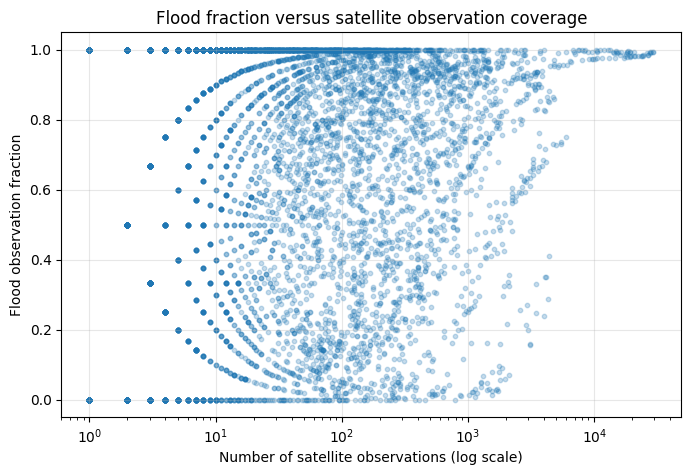

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_flood["flood_observations"],
    daily_flood["flood_observation_fraction"],
    alpha=0.25,
    s=10
)

plt.xscale("log")
plt.xlabel("Number of satellite observations (log scale)")
plt.ylabel("Flood observation fraction")
plt.title("Flood fraction versus satellite observation coverage")
plt.grid(alpha=0.3)

plt.show()

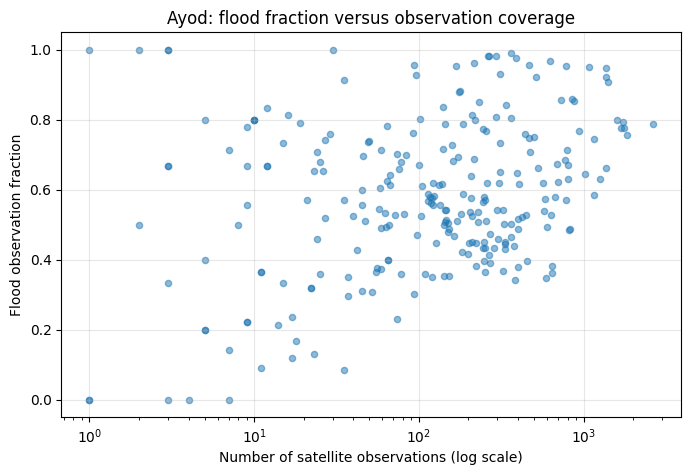

In [42]:
ayod_flood = daily_flood[
    daily_flood["adm2_name"] == "Ayod"
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    ayod_flood["flood_observations"],
    ayod_flood["flood_observation_fraction"],
    alpha=0.5,
    s=20
)

plt.xscale("log")
plt.xlabel("Number of satellite observations (log scale)")
plt.ylabel("Flood observation fraction")
plt.title("Ayod: flood fraction versus observation coverage")
plt.grid(alpha=0.3)

plt.show()

In [43]:
coverage_thresholds = [1, 5, 10, 25, 50, 100, 250, 500]

coverage_sensitivity = []

for threshold in coverage_thresholds:
    subset = daily_flood[
        daily_flood["flood_observations"] >= threshold
    ]

    coverage_sensitivity.append({
        "minimum_observations": threshold,
        "admin2_days_retained": len(subset),
        "percent_retained": 100 * len(subset) / len(daily_flood),
        "admin2_areas_retained": subset["adm2_name"].nunique()
    })

coverage_sensitivity = pd.DataFrame(coverage_sensitivity)

print(coverage_sensitivity)

   minimum_observations  admin2_days_retained  percent_retained  \
0                     1                  7231        100.000000   
1                     5                  5581         77.181579   
2                    10                  4797         66.339372   
3                    25                  3794         52.468538   
4                    50                  2996         41.432720   
5                   100                  2172         30.037339   
6                   250                  1283         17.743051   
7                   500                   782         10.814548   

   admin2_areas_retained  
0                     77  
1                     76  
2                     73  
3                     67  
4                     60  
5                     48  
6                     42  
7                     32  


In [44]:
for threshold in [5, 10, 25, 50, 100]:
    subset = daily_flood[
        daily_flood["flood_observations"] >= threshold
    ]

    print(
        f"Minimum {threshold:>3} observations: "
        f"{subset['adm2_name'].nunique():>2} admin2 areas"
    )

Minimum   5 observations: 76 admin2 areas
Minimum  10 observations: 73 admin2 areas
Minimum  25 observations: 67 admin2 areas
Minimum  50 observations: 60 admin2 areas
Minimum 100 observations: 48 admin2 areas


In [45]:
MIN_OBSERVATIONS = 5

daily_flood_primary = daily_flood[
    daily_flood["flood_observations"] >= MIN_OBSERVATIONS
].copy()

print("Primary flood dataset:")
print("Rows:", len(daily_flood_primary))
print("Admin2 areas:", daily_flood_primary["adm2_name"].nunique())

print("\nObservation count:")
print(
    daily_flood_primary["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]
    )
)

print("\nFlood fraction:")
print(
    daily_flood_primary["flood_observation_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Primary flood dataset:
Rows: 5581
Admin2 areas: 76

Observation count:
count     5581.000000
mean       444.855581
std       1903.747402
min          5.000000
25%         17.000000
50%         59.000000
75%        219.000000
90%        766.000000
95%       1526.000000
max      29292.000000
Name: flood_observations, dtype: float64

Flood fraction:
count    5581.000000
mean        0.686584
std         0.335214
min         0.000000
10%         0.133333
25%         0.422222
50%         0.818182
75%         1.000000
90%         1.000000
95%         1.000000
max         1.000000
Name: flood_observation_fraction, dtype: float64


In [46]:
area_flood_summary = (
    daily_flood_primary
    .groupby("adm2_name")["flood_observation_fraction"]
    .agg(
        days="count",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        max="max"
    )
    .sort_values("median", ascending=False)
)

print(area_flood_summary.head(15))
print("\n...")
print(area_flood_summary.tail(15))

              days      mean  median  p75  p90  max
adm2_name                                          
Abiemnhom        7  1.000000     1.0  1.0  1.0  1.0
Abyei Region     2  1.000000     1.0  1.0  1.0  1.0
Magwi            9  0.971781     1.0  1.0  1.0  1.0
Maban           48  0.999907     1.0  1.0  1.0  1.0
Maridi           8  1.000000     1.0  1.0  1.0  1.0
Ikotos          12  1.000000     1.0  1.0  1.0  1.0
Kapoeta East   128  0.998177     1.0  1.0  1.0  1.0
Ibba             3  1.000000     1.0  1.0  1.0  1.0
Ezo              7  1.000000     1.0  1.0  1.0  1.0
Cueibet         97  0.957382     1.0  1.0  1.0  1.0
Canal/Pigi      95  0.978530     1.0  1.0  1.0  1.0
Budi            16  1.000000     1.0  1.0  1.0  1.0
Wulu            45  0.986135     1.0  1.0  1.0  1.0
Tambura          2  1.000000     1.0  1.0  1.0  1.0
Tonj East       51  1.000000     1.0  1.0  1.0  1.0

...
              days      mean    median       p75       p90       max
adm2_name                                 

In [47]:
daily_flood_detail = (
    flood_with_admin2
    .groupby(["adm2_name", "date"])
    .agg(
        flood_observations=("flood_type", "size"),
        recurring_observations=("flood_type", lambda x: (x == 0).sum()),
        unusual_observations=("flood_type", lambda x: (x == 1).sum())
    )
    .reset_index()
)

daily_flood_detail["recurring_fraction"] = (
    daily_flood_detail["recurring_observations"]
    / daily_flood_detail["flood_observations"]
)

daily_flood_detail["unusual_fraction"] = (
    daily_flood_detail["unusual_observations"]
    / daily_flood_detail["flood_observations"]
)

print(daily_flood_detail.head())

print("\nSummary:")
print(
    daily_flood_detail[
        [
            "flood_observations",
            "recurring_fraction",
            "unusual_fraction"
        ]
    ].describe()
)

   adm2_name       date  flood_observations  recurring_observations  \
0  Abiemnhom 2020-01-05                   1                       0   
1  Abiemnhom 2020-01-10                   1                       0   
2  Abiemnhom 2020-01-12                   4                       0   
3  Abiemnhom 2020-01-14                   4                       0   
4  Abiemnhom 2020-01-21                   2                       0   

   unusual_observations  recurring_fraction  unusual_fraction  
0                     1                 0.0               1.0  
1                     1                 0.0               1.0  
2                     4                 0.0               1.0  
3                     4                 0.0               1.0  
4                     2                 0.0               1.0  

Summary:
       flood_observations  recurring_fraction  unusual_fraction
count         7231.000000         7231.000000       7231.000000
mean           343.824506            0.316854      

In [48]:
MIN_OBSERVATIONS = 5

daily_flood_primary = daily_flood_detail[
    daily_flood_detail["flood_observations"] >= MIN_OBSERVATIONS
].copy()

print("Rows:", len(daily_flood_primary))
print("Admin2 areas:", daily_flood_primary["adm2_name"].nunique())

print("\nUnusual-flood fraction:")
print(
    daily_flood_primary["unusual_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

Rows: 5581
Admin2 areas: 76

Unusual-flood fraction:
count    5581.000000
mean        0.686584
std         0.335214
min         0.000000
10%         0.133333
25%         0.422222
50%         0.818182
75%         1.000000
90%         1.000000
95%         1.000000
max         1.000000
Name: unusual_fraction, dtype: float64


In [49]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print(
    ayod_flood[
        [
            "date",
            "flood_observations",
            "recurring_fraction",
            "unusual_fraction"
        ]
    ].head(20)
)

print("\nAyod unusual-flood fraction:")
print(
    ayod_flood["unusual_fraction"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

          date  flood_observations  recurring_fraction  unusual_fraction
709 2020-01-01                 138            0.384058          0.615942
710 2020-01-02                 179            0.469274          0.530726
711 2020-01-03                 114            0.412281          0.587719
712 2020-01-04                  35            0.428571          0.571429
713 2020-01-05                  40            0.475000          0.525000
714 2020-01-07                 210            0.476190          0.523810
715 2020-01-09                 146            0.458904          0.541096
716 2020-01-10                 150            0.520000          0.480000
717 2020-01-11                 245            0.567347          0.432653
718 2020-01-12                 385            0.657143          0.342857
719 2020-01-13                 221            0.552036          0.447964
720 2020-01-14                 643            0.637636          0.362364
721 2020-01-15                 144            0.458

In [50]:
daily_flood_primary = daily_flood_detail[
    daily_flood_detail["flood_observations"] >= 5
].copy()

# Spatially normalize detected flood pixels by admin2 area
area_lookup = admin2[["adm2_name", "area_sqkm"]].copy()

daily_flood_primary = daily_flood_primary.merge(
    area_lookup,
    on="adm2_name",
    how="left"
)

daily_flood_primary["unusual_observations_per_km2"] = (
    daily_flood_primary["unusual_observations"]
    / daily_flood_primary["area_sqkm"]
)

daily_flood_primary["recurring_observations_per_km2"] = (
    daily_flood_primary["recurring_observations"]
    / daily_flood_primary["area_sqkm"]
)

print(
    daily_flood_primary[
        [
            "adm2_name",
            "date",
            "flood_observations",
            "unusual_observations",
            "recurring_observations",
            "unusual_fraction",
            "unusual_observations_per_km2"
        ]
    ].head()
)

   adm2_name       date  flood_observations  unusual_observations  \
0  Abiemnhom 2020-01-28                   5                     5   
1  Abiemnhom 2020-01-30                   5                     5   
2  Abiemnhom 2020-02-03                   8                     8   
3  Abiemnhom 2020-02-04                   9                     9   
4  Abiemnhom 2020-02-06                  11                    11   

   recurring_observations  unusual_fraction  unusual_observations_per_km2  
0                       0               1.0                      0.002077  
1                       0               1.0                      0.002077  
2                       0               1.0                      0.003322  
3                       0               1.0                      0.003738  
4                       0               1.0                      0.004568  


In [51]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print("Ayod unusual observations:")
print(
    ayod_flood["unusual_observations"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nAyod unusual observations per km²:")
print(
    ayod_flood["unusual_observations_per_km2"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Ayod unusual observations:
count     241.000000
mean      198.290456
std       304.711952
min         0.000000
25%        28.000000
50%        89.000000
75%       205.000000
90%       507.000000
95%       795.000000
99%      1365.000000
max      2080.000000
Name: unusual_observations, dtype: float64

Ayod unusual observations per km²:
count    241.000000
mean       0.014744
std        0.022657
min        0.000000
25%        0.002082
50%        0.006618
75%        0.015243
90%        0.037698
95%        0.059112
99%        0.101493
max        0.154657
Name: unusual_observations_per_km2, dtype: float64


In [52]:
ayod_flood = daily_flood_primary[
    daily_flood_primary["adm2_name"] == "Ayod"
].copy()

print("Ayod unusual observations:")
print(
    ayod_flood["unusual_observations"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\nAyod unusual observations per km²:")
print(
    ayod_flood["unusual_observations_per_km2"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Ayod unusual observations:
count     241.000000
mean      198.290456
std       304.711952
min         0.000000
25%        28.000000
50%        89.000000
75%       205.000000
90%       507.000000
95%       795.000000
99%      1365.000000
max      2080.000000
Name: unusual_observations, dtype: float64

Ayod unusual observations per km²:
count    241.000000
mean       0.014744
std        0.022657
min        0.000000
25%        0.002082
50%        0.006618
75%        0.015243
90%        0.037698
95%        0.059112
99%        0.101493
max        0.154657
Name: unusual_observations_per_km2, dtype: float64


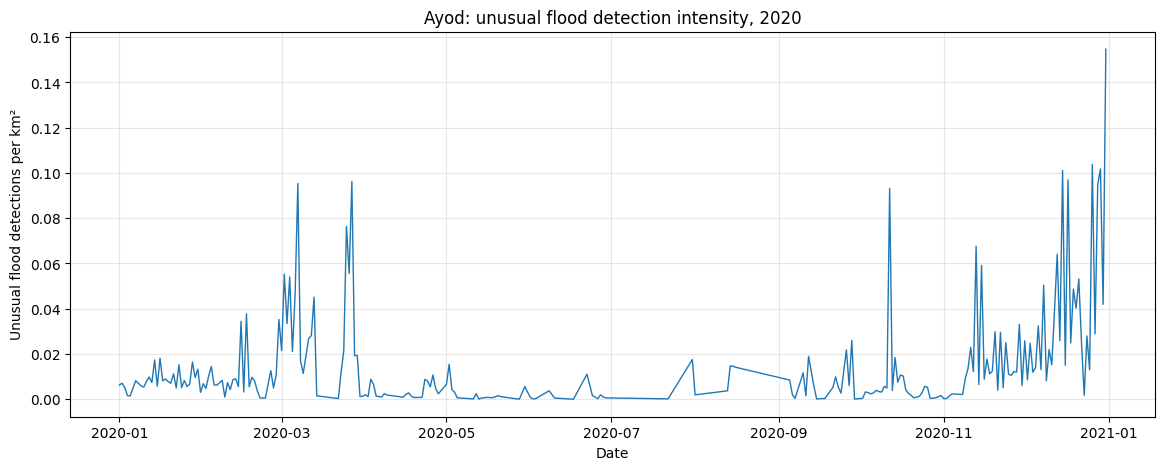

In [53]:
ayod_flood_plot = (
    daily_flood_primary[
        daily_flood_primary["adm2_name"] == "Ayod"
    ][
        [
            "date",
            "unusual_observations",
            "unusual_observations_per_km2"
        ]
    ]
    .sort_values("date")
)

plt.figure(figsize=(14, 5))

plt.plot(
    ayod_flood_plot["date"],
    ayod_flood_plot["unusual_observations_per_km2"],
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Unusual flood detections per km²")
plt.title("Ayod: unusual flood detection intensity, 2020")
plt.grid(alpha=0.3)

plt.show()

In [54]:
ayod_compare = ayod_weather.copy()

ayod_compare = ayod_compare.join(
    ayod_flood_plot.set_index("date")[
        ["unusual_observations_per_km2"]
    ],
    how="left"
)

# No detected unusual flood pixels on a date = zero detections
ayod_compare["unusual_observations_per_km2"] = (
    ayod_compare["unusual_observations_per_km2"].fillna(0)
)

print(ayod_compare.head(15))

            precipitation_m  runoff_m  precipitation_mm  runoff_mm  \
date                                                                 
2020-01-01              0.0       0.0               0.0        0.0   
2020-01-02              0.0       0.0               0.0        0.0   
2020-01-03              0.0       0.0               0.0        0.0   
2020-01-04              0.0       0.0               0.0        0.0   
2020-01-05              0.0       0.0               0.0        0.0   
2020-01-06              0.0       0.0               0.0        0.0   
2020-01-07              0.0       0.0               0.0        0.0   
2020-01-08              0.0       0.0               0.0        0.0   
2020-01-09              0.0       0.0               0.0        0.0   
2020-01-10              0.0       0.0               0.0        0.0   
2020-01-11              0.0       0.0               0.0        0.0   
2020-01-12              0.0       0.0               0.0        0.0   
2020-01-13          

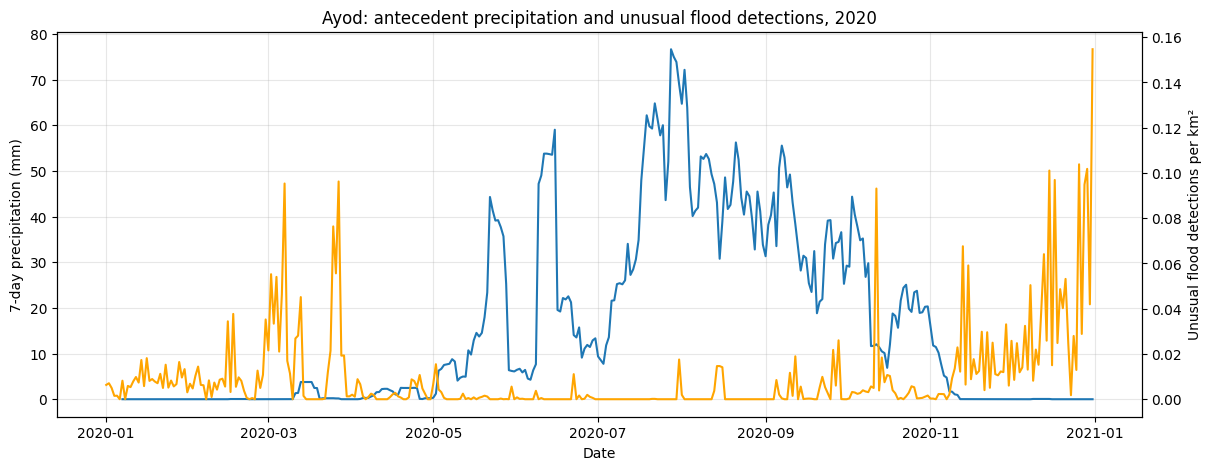

In [57]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    ayod_compare.index,
    ayod_compare["precip_7d_mm"],
    label="7-day precipitation"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("7-day precipitation (mm)")

ax2 = ax1.twinx()

ax2.plot(
    ayod_compare.index,
    ayod_compare["unusual_observations_per_km2"],
    label="Unusual flood detections",
    color="orange"
)

ax2.set_ylabel("Unusual flood detections per km²")

ax1.set_title(
    "Ayod: antecedent precipitation and unusual flood detections, 2020"
)

ax1.grid(alpha=0.3)

plt.show()

In [58]:
ayod_events = (
    ayod_compare[
        ayod_compare["unusual_observations_per_km2"] > 0
    ]
    .copy()
)

# Rank all observed unusual-flood days
top_ayod_flood_days = (
    ayod_events
    .sort_values(
        "unusual_observations_per_km2",
        ascending=False
    )
    .head(20)
)

print(
    top_ayod_flood_days[
        [
            "unusual_observations_per_km2",
            "precipitation_mm",
            "precip_3d_mm",
            "precip_7d_mm",
            "precip_14d_mm",
            "runoff_mm",
            "runoff_3d_mm",
            "runoff_7d_mm",
            "runoff_14d_mm"
        ]
    ].to_string()
)

            unusual_observations_per_km2  precipitation_mm  precip_3d_mm  precip_7d_mm  precip_14d_mm  runoff_mm  runoff_3d_mm  runoff_7d_mm  runoff_14d_mm
date                                                                                                                                                       
2020-12-31                      0.154657          0.000000      0.000000      0.000000       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-26                      0.103798          0.000000      0.000000      0.002028       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-29                      0.101791          0.000000      0.000000      0.000000       0.002028   0.000000      0.000000      0.000000       0.000000
2020-12-15                      0.101047          0.000000      0.000000      0.058572       0.058610   0.000000      0.000000      0.000108       0.000108
2020-12-17                      0.096883          0.000000      

In [59]:
# Start from Ayod's flood signal
ayod_lag_analysis = ayod_compare.copy()

# Weather variables shifted backwards:
# lag = 1 means weather from the previous day
# lag = 3 means weather ending 3 days before the flood date, etc.

for lag in [1, 3, 7, 14, 21, 30]:
    ayod_lag_analysis[f"precip_1d_before_{lag}d"] = (
        ayod_lag_analysis["precipitation_mm"].shift(lag)
    )

    ayod_lag_analysis[f"precip_7d_before_{lag}d"] = (
        ayod_lag_analysis["precip_7d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"precip_14d_before_{lag}d"] = (
        ayod_lag_analysis["precip_14d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"runoff_7d_before_{lag}d"] = (
        ayod_lag_analysis["runoff_7d_mm"].shift(lag)
    )

    ayod_lag_analysis[f"runoff_14d_before_{lag}d"] = (
        ayod_lag_analysis["runoff_14d_mm"].shift(lag)
    )

print(
    ayod_lag_analysis[
        [
            "unusual_observations_per_km2",
            "precip_7d_before_1d",
            "precip_7d_before_3d",
            "precip_7d_before_7d",
            "precip_14d_before_14d",
            "runoff_14d_before_14d"
        ]
    ].head(20)
)

            unusual_observations_per_km2  precip_7d_before_1d  \
date                                                            
2020-01-01                      0.006320                  NaN   
2020-01-02                      0.007064                  NaN   
2020-01-03                      0.004982                  NaN   
2020-01-04                      0.001487                  NaN   
2020-01-05                      0.001561                  NaN   
2020-01-06                      0.000000                  NaN   
2020-01-07                      0.008179                  NaN   
2020-01-08                      0.000000                  0.0   
2020-01-09                      0.005874                  0.0   
2020-01-10                      0.005353                  0.0   
2020-01-11                      0.007882                  0.0   
2020-01-12                      0.009815                  0.0   
2020-01-13                      0.007361                  0.0   
2020-01-14               

In [60]:
top_flood_dates = (
    ayod_lag_analysis[
        ayod_lag_analysis["unusual_observations_per_km2"] > 0
    ]
    .sort_values(
        "unusual_observations_per_km2",
        ascending=False
    )
    .head(20)
)

columns_to_show = [
    "unusual_observations_per_km2",
    "precip_7d_before_1d",
    "precip_7d_before_3d",
    "precip_7d_before_7d",
    "precip_14d_before_7d",
    "precip_14d_before_14d",
    "runoff_7d_before_7d",
    "runoff_14d_before_14d"
]

print(
    top_flood_dates[columns_to_show]
    .to_string()
)

            unusual_observations_per_km2  precip_7d_before_1d  precip_7d_before_3d  precip_7d_before_7d  precip_14d_before_7d  precip_14d_before_14d  runoff_7d_before_7d  runoff_14d_before_14d
date                                                                                                                                                                                            
2020-12-31                      0.154657             0.000000             0.002028             0.002028              0.002028               0.058572             0.000000               0.000108
2020-12-26                      0.103798             0.002028             0.002028             0.000000              0.058572               0.058610             0.000000               0.000108
2020-12-29                      0.101791             0.002028             0.002028             0.002028              0.060601               0.058610             0.000000               0.000108
2020-12-15                      0.1

In [61]:
ayod_analysis = ayod_lag_analysis.copy()

# Only consider days for which the flood signal is available
flood_values = ayod_analysis[
    "unusual_observations_per_km2"
]

high_flood_threshold = flood_values.quantile(0.90)

ayod_analysis["high_flood_day"] = (
    ayod_analysis["unusual_observations_per_km2"]
    >= high_flood_threshold
)

print("90th-percentile unusual-flood threshold:")
print(high_flood_threshold)

print("\nHigh-flood days:")
print(
    ayod_analysis["high_flood_day"].value_counts()
)

90th-percentile unusual-flood threshold:
0.025949602021848532

High-flood days:
high_flood_day
False    329
True      37
Name: count, dtype: int64


In [62]:
weather_columns = [
    "precip_7d_before_1d",
    "precip_7d_before_3d",
    "precip_7d_before_7d",
    "precip_14d_before_7d",
    "precip_14d_before_14d",
    "runoff_7d_before_1d",
    "runoff_7d_before_3d",
    "runoff_7d_before_7d",
    "runoff_14d_before_7d",
    "runoff_14d_before_14d"
]

high_flood_summary = (
    ayod_analysis
    .groupby("high_flood_day")[weather_columns]
    .median()
    .T
)

high_flood_summary.columns = [
    "other_days",
    "top_10pct_flood_days"
]

print(high_flood_summary)

                       other_days  top_10pct_flood_days
precip_7d_before_1d      8.419455              0.002028
precip_7d_before_3d      8.671555              0.002028
precip_7d_before_7d      9.240706              0.002028
precip_14d_before_7d    26.939981              0.043681
precip_14d_before_14d   28.092844              0.043681
runoff_7d_before_1d      0.054157              0.000000
runoff_7d_before_3d      0.057025              0.000000
runoff_7d_before_7d      0.062517              0.000000
runoff_14d_before_7d     0.245341              0.000108
runoff_14d_before_14d    0.247227              0.000021


In [63]:
high_flood_summary["difference"] = (
    high_flood_summary["top_10pct_flood_days"]
    - high_flood_summary["other_days"]
)

high_flood_summary["ratio"] = (
    high_flood_summary["top_10pct_flood_days"]
    / high_flood_summary["other_days"].replace(0, np.nan)
)

print(
    high_flood_summary.sort_values(
        "difference",
        ascending=False
    )
)

                       other_days  top_10pct_flood_days  difference     ratio
runoff_7d_before_1d      0.054157              0.000000   -0.054157  0.000000
runoff_7d_before_3d      0.057025              0.000000   -0.057025  0.000000
runoff_7d_before_7d      0.062517              0.000000   -0.062517  0.000000
runoff_14d_before_7d     0.245341              0.000108   -0.245233  0.000440
runoff_14d_before_14d    0.247227              0.000021   -0.247206  0.000087
precip_7d_before_1d      8.419455              0.002028   -8.417427  0.000241
precip_7d_before_3d      8.671555              0.002028   -8.669527  0.000234
precip_7d_before_7d      9.240706              0.002028   -9.238677  0.000220
precip_14d_before_7d    26.939981              0.043681  -26.896301  0.001621
precip_14d_before_14d   28.092844              0.043681  -28.049163  0.001555


In [64]:
daily_flood_final_2020 = daily_flood_detail.copy()

daily_flood_final_2020 = daily_flood_final_2020.merge(
    admin2[["adm2_name", "area_sqkm"]],
    on="adm2_name",
    how="left"
)

daily_flood_final_2020["unusual_observations_per_km2"] = (
    daily_flood_final_2020["unusual_observations"]
    / daily_flood_final_2020["area_sqkm"]
)

daily_flood_final_2020["recurring_observations_per_km2"] = (
    daily_flood_final_2020["recurring_observations"]
    / daily_flood_final_2020["area_sqkm"]
)

print(daily_flood_final_2020.shape)

print(
    daily_flood_final_2020[
        [
            "adm2_name",
            "date",
            "flood_observations",
            "unusual_observations",
            "recurring_observations",
            "unusual_fraction",
            "unusual_observations_per_km2"
        ]
    ].head()
)

(7231, 10)
   adm2_name       date  flood_observations  unusual_observations  \
0  Abiemnhom 2020-01-05                   1                     1   
1  Abiemnhom 2020-01-10                   1                     1   
2  Abiemnhom 2020-01-12                   4                     4   
3  Abiemnhom 2020-01-14                   4                     4   
4  Abiemnhom 2020-01-21                   2                     2   

   recurring_observations  unusual_fraction  unusual_observations_per_km2  
0                       0               1.0                      0.000415  
1                       0               1.0                      0.000415  
2                       0               1.0                      0.001661  
3                       0               1.0                      0.001661  
4                       0               1.0                      0.000831  


In [65]:
print(
    daily_flood_final_2020["flood_observations"]
    .describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print("\nRecords with 1–4 detected flood pixels:")
print(
    (daily_flood_final_2020["flood_observations"] < 5).sum()
)

count     7231.000000
mean       343.824506
std       1682.757442
min          1.000000
25%          5.000000
50%         29.000000
75%        142.000000
90%        550.000000
95%       1216.500000
99%       5084.700000
max      29292.000000
Name: flood_observations, dtype: float64

Records with 1–4 detected flood pixels:
1650


## Progress checkpoint — 2020 exploratory analysis
The 2020 workflow for Ayod and other admin2 areas has been established. ERA5 precipitation and runoff were spatially aggregated to admin2 using area-weighted intersections of the 0.25° grid cells. Flood observations were spatially assigned to admin2 and separated into recurring and unusual flood detections.  
Exploratory analysis of Ayod suggests that unusual flood detection intensity does not consistently follow high local precipitation or runoff. Some strong unusual-flood detection days have substantial antecedent rainfall/runoff, while others occur after very little local rainfall. This suggests that a simple local rainfall threshold is unlikely to explain all unusual flooding.
Next step: scale the validated workflow to 2000–2025, construct a complete admin2-day panel, and investigate whether antecedent precipitation/runoff relationships are consistent across years and areas.